In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import wrds

In [3]:
db = wrds.Connection(wrds_username="dengtianle")

Loading library list...
Done


In [6]:
sql = """
    select date, prc
    from crsp.dsf
    where permno = 14593  -- Apple 的 permno
    and date >= '2020-01-01'
    order by date
"""

In [7]:
df = db.raw_sql(sql, date_cols=['date'])
db.close()

In [8]:
df = df.dropna()
df.set_index('date', inplace=True)
df['ret'] = df['prc'].pct_change()

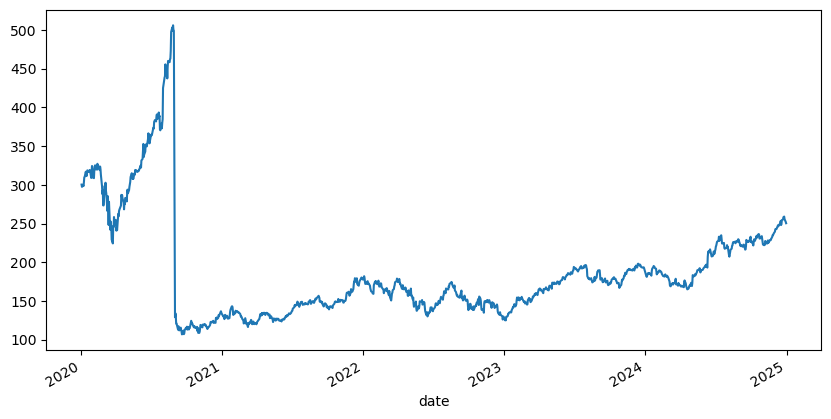

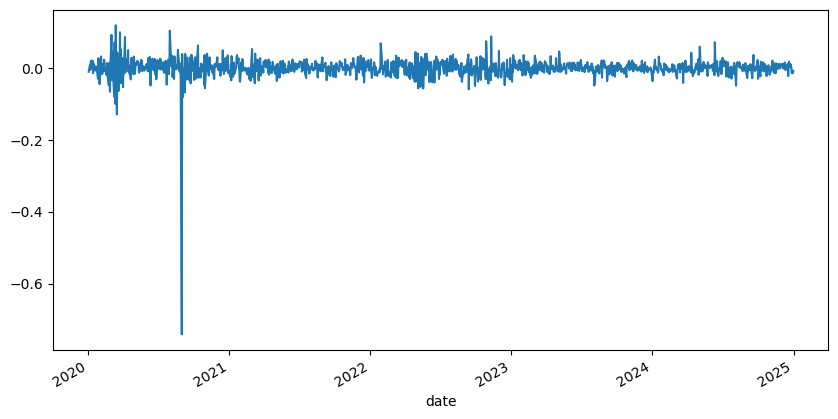

In [9]:
plt.figure(figsize=(10,5))
df['prc'].plot()
plt.savefig('price.png')

plt.figure(figsize=(10,5))
df['ret'].plot()
plt.savefig('return.png')